<h2>Image Deblurring for License Plate OCR</h2>

<h3>EDA</h3>

In [16]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split


In [17]:
# Paths
src_dir = 'testing_images/clear_images'
images = os.listdir(src_dir)
dst_dir = 'testing_images/blur_images'

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

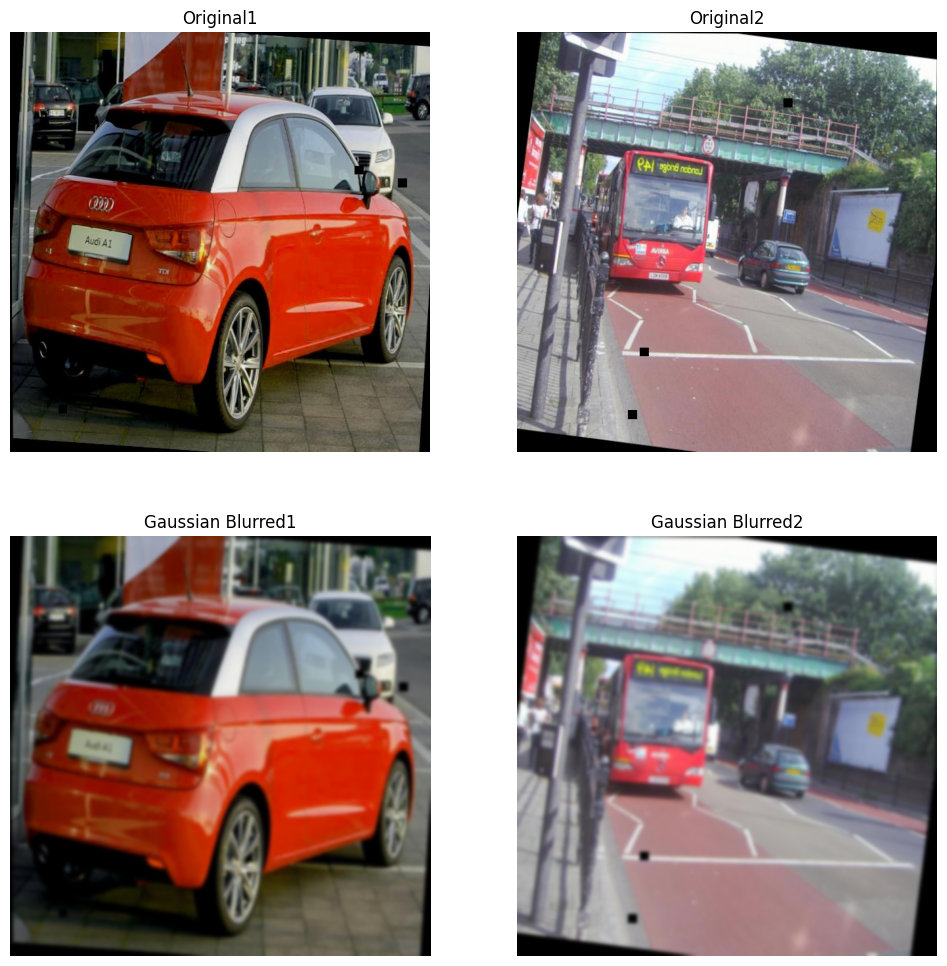

In [18]:
img1 = cv2.imread(f"{src_dir}/{images[43]}")
img2 = cv2.imread(f"{src_dir}/{images[144]}")

blurred1 = cv2.GaussianBlur(img1, (15, 15), 0) 
blurred2 = cv2.GaussianBlur(img2, (15, 15), 0)  

img_rgb1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img_rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
blurred_rgb1 = cv2.cvtColor(blurred1, cv2.COLOR_BGR2RGB)
blurred_rgb2 = cv2.cvtColor(blurred2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb1)
plt.title("Original1")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_rgb2)
plt.title("Original2")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(blurred_rgb1)
plt.title("Gaussian Blurred1")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(blurred_rgb2)
plt.title("Gaussian Blurred2")
plt.axis("off")

In [19]:
def applyGaussianBlur(i,img):
    img = cv2.imread(f"{src_dir}/{images[i]}")
    blur = cv2.GaussianBlur(img, (15, 15), 0)
    try:
        cv2.imwrite(f"{dst_dir}/{images[i]}", blur)
    except:
        print(f"Error writing image {images[i]}")

for i, img in tqdm(enumerate(images), total=len(images)):
    # applyGaussianBlur(i,img)
    pass

print('DONE')

100%|██████████| 396/396 [00:00<?, ?it/s]

DONE


In [20]:
# Checking that the blur and sharp images correspond correctly

gauss_blur = os.listdir(src_dir)
gauss_blur.sort()
sharp = os.listdir(dst_dir)
sharp.sort()

x_blur = []
for i in range(len(gauss_blur)):
    x_blur.append(gauss_blur[i])

y_sharp = []
for i in range(len(sharp)):
    y_sharp.append(sharp[i])

# Check .ipynb
print(len(x_blur))
print(len(y_sharp))
print(x_blur[1])
print(y_sharp[1])

396
396
000228608388803f_jpg.rf.924b00a39d9fad9da20e784dacfc41b7.jpg
000228608388803f_jpg.rf.924b00a39d9fad9da20e784dacfc41b7.jpg


Dataset Summary
Total images: 396
Image formats: {'.jpg'}
Channel types: {'RGB'}
Resolution (min WxH): 640x640
Resolution (max WxH): 640x640
Average resolution: 640x640
Pixel intensity range: 0 – 255
Mean pixel intensity: 112.15


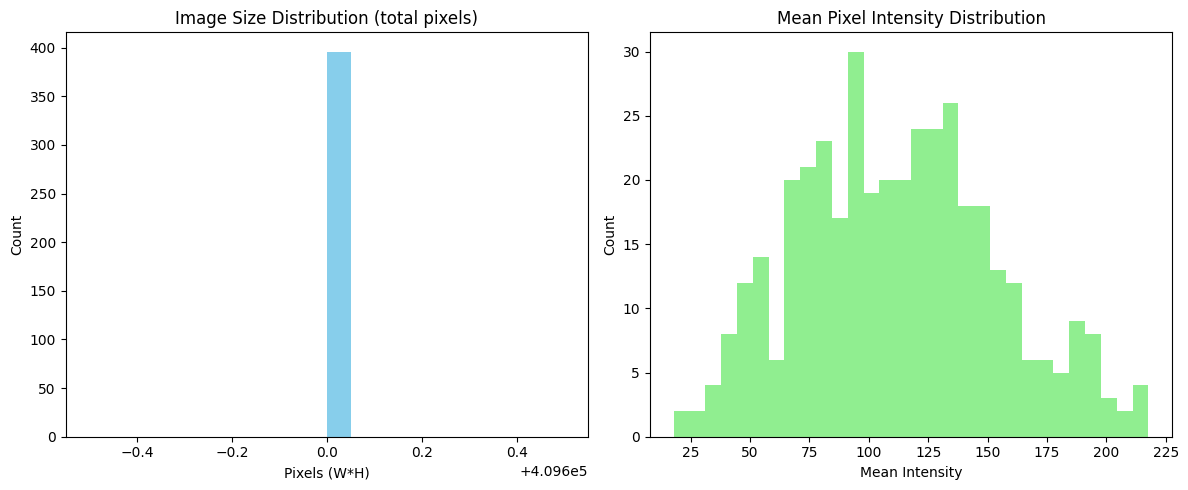

In [21]:
widths, heights = [], []
channels_list = []
pixel_means, pixel_mins, pixel_maxs = [], [], []
formats = []

for img_name in images:
    img_path = os.path.join(src_dir, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        print(f"Error reading {img_name}")
        continue

    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)

    if len(img.shape) == 2:
        channels_list.append("Grayscale")
    elif img.shape[2] == 3:
        channels_list.append("RGB")
    elif img.shape[2] == 4:
        channels_list.append("RGBA")
    else:
        channels_list.append(f"Unknown-{img.shape}")

    ext = os.path.splitext(img_name)[1].lower()
    formats.append(ext)

    pixel_mins.append(np.min(img))
    pixel_maxs.append(np.max(img))
    pixel_means.append(np.mean(img))

print("Dataset Summary")
print(f"Total images: {len(images)}")
print(f"Image formats: {set(formats)}")
print(f"Channel types: {set(channels_list)}")
print(f"Resolution (min WxH): {min(widths)}x{min(heights)}")
print(f"Resolution (max WxH): {max(widths)}x{max(heights)}")
print(f"Average resolution: {int(np.mean(widths))}x{int(np.mean(heights))}")
print(f"Pixel intensity range: {min(pixel_mins)} – {max(pixel_maxs)}")
print(f"Mean pixel intensity: {np.mean(pixel_means):.2f}")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist([w*h for w,h in zip(widths, heights)], bins=20, color='skyblue')
plt.title("Image Size Distribution (total pixels)")
plt.xlabel("Pixels (W*H)")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(pixel_means, bins=30, color='lightgreen')
plt.title("Mean Pixel Intensity Distribution")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

<h3>Model Architectures</h3>

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 128, kernel_size=5, padding=1)
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 3, kernel_size=1, padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        return x
    

class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(16, 3, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(64)
        self.bn5 = nn.BatchNorm2d(64)
        self.bn6 = nn.BatchNorm2d(32)
        self.bn7 = nn.BatchNorm2d(16)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = F.relu(self.bn7(self.conv7(x)))
        x = self.conv8(x)
        return x

class SimpleAE(nn.Module):
    def __init__(self):
        super(SimpleAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=5),
            nn.ReLU(True))
        self.decoder = nn.Sequential(             
            nn.ConvTranspose2d(64, 32, kernel_size=5),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=5),
            nn.ReLU(True))
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

<h3> Models Testing

In [24]:
import os
import uuid
import zipfile
from pathlib import Path
from typing import Dict, Tuple, List

import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
MODELS_DIR = Path("app/models")
CNN_WEIGHTS = MODELS_DIR / "model_cnn.pth"
DEEPCNN_WEIGHTS = MODELS_DIR / "model_deepcnn.pth"
AE_WEIGHTS = MODELS_DIR / "model_sae.pth"

TEST_IMAGES_DIR = Path("testing_images") 
OUT_DIR = Path("test_run")
RESULTS_CSV = OUT_DIR / "results.csv"
OVERALL_CSV = OUT_DIR / "overall_metrics.csv"
ZIP_NAME = OUT_DIR / "test_results.zip"
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Current device :",DEVICE)

Current device : cpu


In [33]:
device = DEVICE

# Initialize models
cnn = CNN().to(device).eval()
deepcnn = DeepCNN().to(device).eval()
ae = SimpleAE().to(device).eval()

models_map = {
    "CNN": {"model": cnn, "weights": CNN_WEIGHTS, "metrics": []},
    "DeepCNN": {"model": deepcnn, "weights": DEEPCNN_WEIGHTS, "metrics": []},
    "SimpleAE": {"model": ae, "weights": AE_WEIGHTS, "metrics": []},
}

for name, entry in models_map.items():
    if entry["weights"].exists():
        raw = torch.load(str(entry["weights"]), map_location=device)
        if isinstance(raw, dict) and "state_dict" in raw:
            raw = raw["state_dict"]
        cleaned = {k.replace("module.", ""): v for k, v in raw.items()}
        try:
            entry["model"].load_state_dict(cleaned, strict=True)
        except:
            entry["model"].load_state_dict(cleaned, strict=False)
        print(f"{name} weights loaded.")
    else:
        print(f"{name} weights NOT found. Random init used.")


CNN weights loaded.
DeepCNN weights loaded.
SimpleAE weights loaded.


In [35]:
blur_dir = TEST_IMAGES_DIR / "blur_images"
gt_dir = TEST_IMAGES_DIR / "clear_images"

blur_images = sorted([p for p in blur_dir.glob("*") if p.suffix.lower() in (".jpg",".jpeg",".png",".bmp")])
gt_images_all = sorted([p for p in gt_dir.glob("*") if p.suffix.lower() in (".jpg",".jpeg",".png",".bmp")])

gt_map = {p.name: p for p in gt_images_all}
gt_images = [gt_map.get(p.name, None) for p in blur_images]

len(blur_images), len(gt_images)

(396, 396)

In [36]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

results = []  # will store dicts

In [37]:
for idx, bpath in enumerate(blur_images):
    img = cv2.imread(str(bpath), cv2.IMREAD_COLOR)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp = transform(img).unsqueeze(0).to(device)

    gtpath = gt_images[idx]
    if gtpath is not None:
        gt_img = cv2.imread(str(gtpath), cv2.IMREAD_COLOR)
        gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
        gt_resized = cv2.resize(gt_img, (224,224))
        gt_np = (gt_resized.astype(np.float32))/255.0
    else:
        gt_np = None

    for mname, entry in models_map.items():
        with torch.no_grad():
            out = entry["model"](inp)
            if out.shape[-1] != 224 or out.shape[-2] != 224:
                out = F.interpolate(out, size=(224,224), mode='bilinear', align_corners=False)

        t = out[0].detach().cpu().numpy()
        t = np.transpose(t, (1,2,0))
        t = np.clip(t, 0.0, 1.0)

        row = {"image": bpath.name, "model": mname}

        if gt_np is not None:
            mse = float(mean_squared_error(gt_np, t))
            mae = float(np.mean(np.abs(gt_np - t)))
            try:
                psnr = float(peak_signal_noise_ratio(gt_np, t, data_range=1.0))
            except:
                psnr = float("nan")
            try:
                ssim = float(structural_similarity(gt_np, t, data_range=1.0, multichannel=True))
            except:
                ssim = float("nan")
            row.update({"mse": mse, "mae": mae, "psnr": psnr, "ssim": ssim})
            entry["metrics"].append(row)
        else:
            row.update({"mse": None, "mae": None, "psnr": None, "ssim": None})

        results.append(row)

    print(f"Processed {idx+1}/{len(blur_images)}")

Processed 1/396
Processed 2/396
Processed 3/396
Processed 4/396
Processed 5/396
Processed 6/396
Processed 7/396
Processed 8/396
Processed 9/396
Processed 10/396
Processed 11/396
Processed 12/396
Processed 13/396
Processed 14/396
Processed 15/396
Processed 16/396
Processed 17/396
Processed 18/396
Processed 19/396
Processed 20/396
Processed 21/396
Processed 22/396
Processed 23/396
Processed 24/396
Processed 25/396
Processed 26/396
Processed 27/396
Processed 28/396
Processed 29/396


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)
results_df

In [ ]:
summary = []
for mname, entry in models_map.items():
    if not entry["metrics"]:
        continue
    dfm = pd.DataFrame(entry["metrics"])
    summary.append({
        "model": mname,
        "mse_mean": dfm["mse"].mean(),
        "mae_mean": dfm["mae"].mean(),
        "psnr_mean": dfm["psnr"].mean(),
        "ssim_mean": dfm["ssim"].mean(),
    })

summary_df = pd.DataFrame(summary)
summary_df

In [ ]:
metrics_to_plot = ["mse_mean", "mae_mean", "psnr_mean", "ssim_mean"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6,4))
    plt.bar(summary_df["model"], summary_df[metric])
    plt.title(f"{metric} comparison across models")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.show()